In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from bokeh.plotting import figure, show
from bokeh.models import HoverTool, ColumnDataSource
from bokeh.io import output_notebook

output_notebook()

df = pd.read_csv("techstore_chile_2024.csv")


display(df.head(5))

display(df.shape)

display(df.info())

display(df.isnull().sum())

Loading BokehJS ...

,mes,categoria,unidades,precio_unitario,ingresos,nps,devueltos
0,1,Accesorios,639,26.6,16997.4,79,6
1,1,Accesorios,603,27.4,16522.2,83,4
2,1,Accesorios,617,27.1,16720.7,88,3
3,1,Accesorios,670,25.8,17286.0,90,5
4,1,Accesorios,586,24.6,14415.6,84,1


(300, 7)

<class 'pandas.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   mes              300 non-null    int64  
 1   categoria        300 non-null    str    
 2   unidades         300 non-null    int64  
 3   precio_unitario  300 non-null    float64
 4   ingresos         300 non-null    float64
 5   nps              300 non-null    int64  
 6   devueltos        300 non-null    int64  
dtypes: float64(2), int64(4), str(1)
memory usage: 16.5 KB


None

mes                0
categoria          0
unidades           0
precio_unitario    0
ingresos           0
nps                0
devueltos          0
dtype: int64

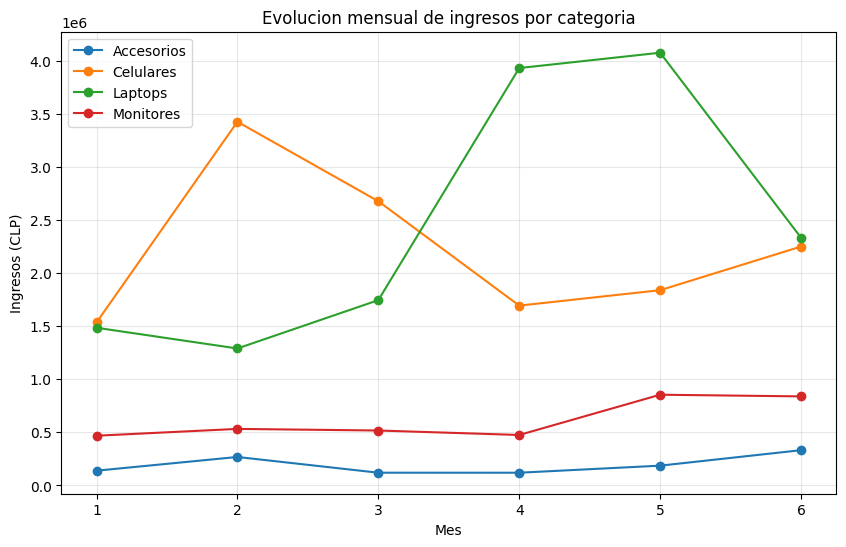

In [2]:
ingresos_cat = df.groupby(['mes', 'categoria'])['ingresos'].sum().unstack()

fig, ax = plt.subplots(figsize=(10, 6))
for cat in ingresos_cat.columns:
    ax.plot(ingresos_cat.index, ingresos_cat[cat], marker='o', label=cat)

ax.set_title('Evolucion mensual de ingresos por categoria')
ax.set_xlabel('Mes')
ax.set_ylabel('Ingresos (CLP)')
ax.set_xticks(range(1, 7))
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

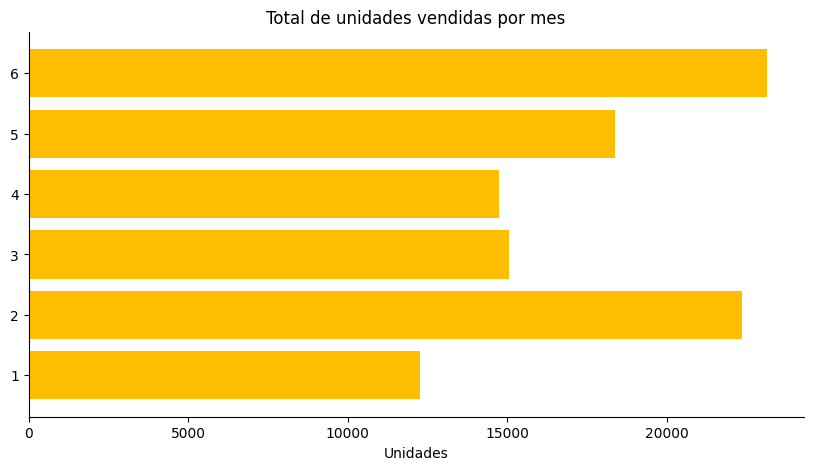

In [3]:
unidades_mes = df.groupby('mes')['unidades'].sum()
colores = ['#FFBF00' if v > 1400 else '#0D9488' for v in unidades_mes]

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(unidades_mes.index.astype(str), unidades_mes.values, color=colores)

ax.set_title('Total de unidades vendidas por mes')
ax.set_xlabel('Unidades')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.show()

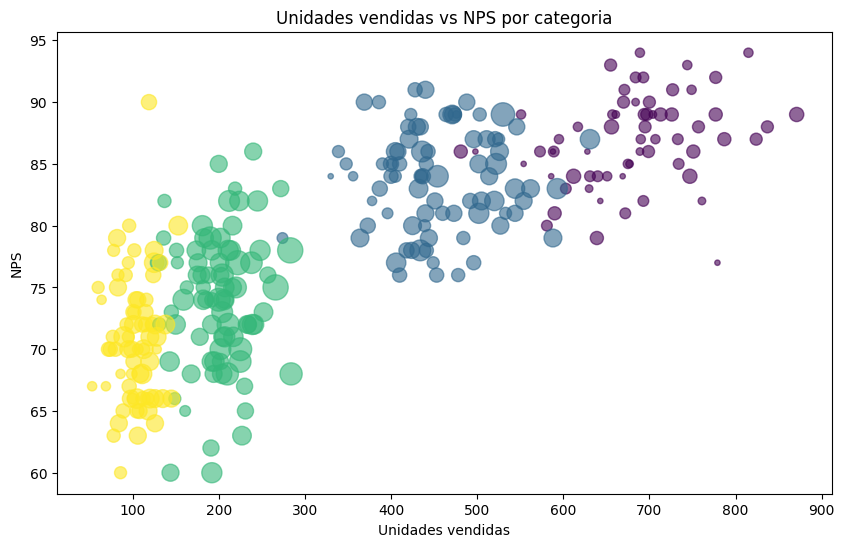

In [4]:
fig, ax = plt.subplots(figsize=(10, 6))
scatter = ax.scatter(df['unidades'], df['nps'], c=df['categoria'].astype('category').cat.codes, 
                     s=df['devueltos'] * 15, alpha=0.6, cmap='viridis')

ax.set_title('Unidades vendidas vs NPS por categoria')
ax.set_xlabel('Unidades vendidas')
ax.set_ylabel('NPS')
plt.show()

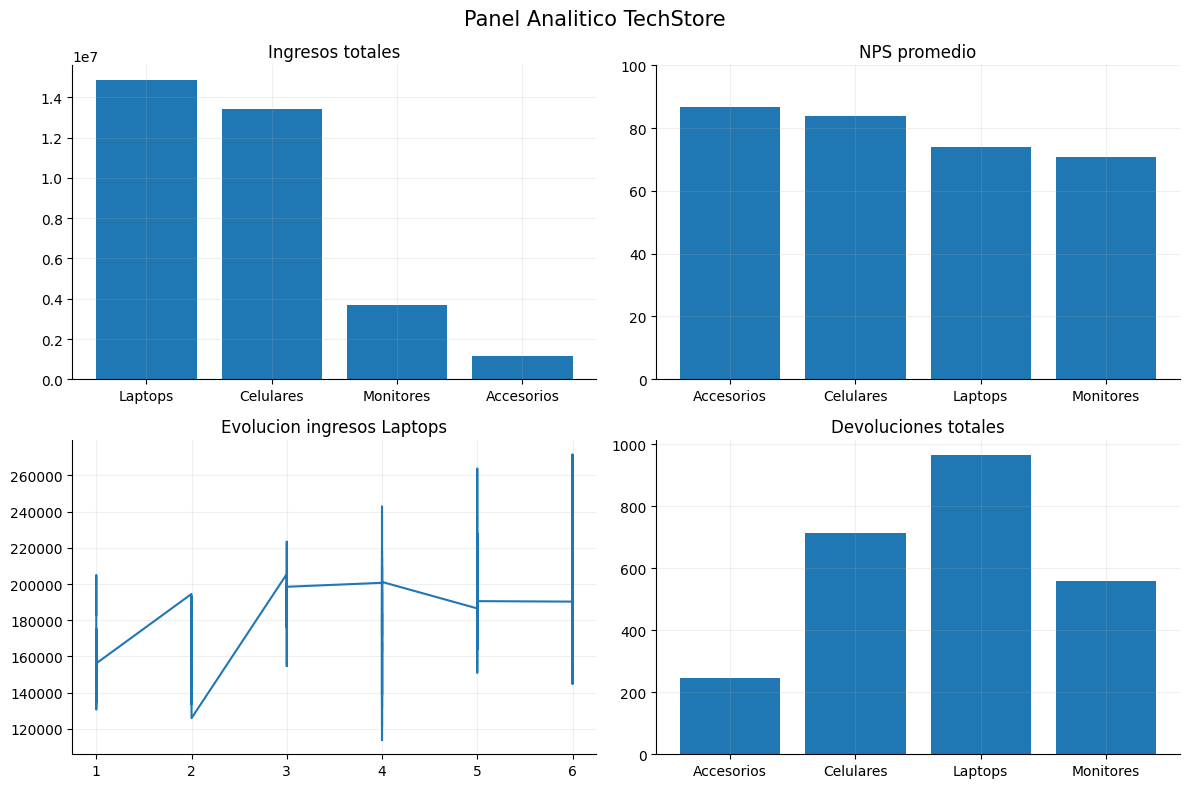

In [5]:
ingresos_cat_tot = df.groupby('categoria')['ingresos'].sum().sort_values(ascending=False)
nps_prom = df.groupby('categoria')['nps'].mean()
dev_tot = df.groupby('categoria')['devueltos'].sum()
laptops = df[df['categoria'] == 'Laptops'].sort_values('mes')

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12, 8))
fig.suptitle('Panel Analitico TechStore', fontsize=15)

axes[0,0].bar(ingresos_cat_tot.index, ingresos_cat_tot.values)
axes[0,0].set_title('Ingresos totales')

axes[0,1].bar(nps_prom.index, nps_prom.values)
axes[0,1].set_title('NPS promedio')
axes[0,1].set_ylim(0, 100)

axes[1,0].plot(laptops['mes'], laptops['ingresos'])
axes[1,0].set_title('Evolucion ingresos Laptops')

axes[1,1].bar(dev_tot.index, dev_tot.values)
axes[1,1].set_title('Devoluciones totales')

for ax in axes.flat:
    ax.grid(True, alpha=0.2)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

In [6]:
ingresos_mes = df.groupby('mes').agg({'ingresos': 'sum', 'unidades': 'sum'}).reset_index()
ingresos_mes['mes_str'] = ingresos_mes['mes'].astype(str)
source = ColumnDataSource(ingresos_mes)

p = figure(x_range=ingresos_mes['mes_str'].tolist(), title='Ingresos mensuales', 
           height=400, width=700, tools='pan,wheel_zoom,reset')

p.vbar(x='mes_str', top='ingresos', width=0.7, source=source, color='#0D9488')

hover = HoverTool(tooltips=[
    ('Mes', '@mes_str'),
    ('Ingresos', '@ingresos{0,0}'),
    ('Unidades', '@unidades')
])
p.add_tools(hover)

p.yaxis.axis_label = 'Ingresos (CLP)'
show(p)